#Telco Customer Churn

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,PowerTransformer,OrdinalEncoder,OneHotEncoder, StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, fbeta_score, precision_recall_curve, roc_curve, roc_auc_score, precision_recall_curve, accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import time

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/KarthiObli/TelcoCustomerChurn/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop('customerID',axis=1,inplace=True)

In [ ]:
df_corr = df[:]

In [ ]:
le = LabelEncoder()

In [ ]:
for i in df_corr.select_dtypes(include='object').columns:
  df_corr[i] = le.fit_transform(df_corr[i])

In [ ]:
corr = df_corr.corr()

<Axes: >

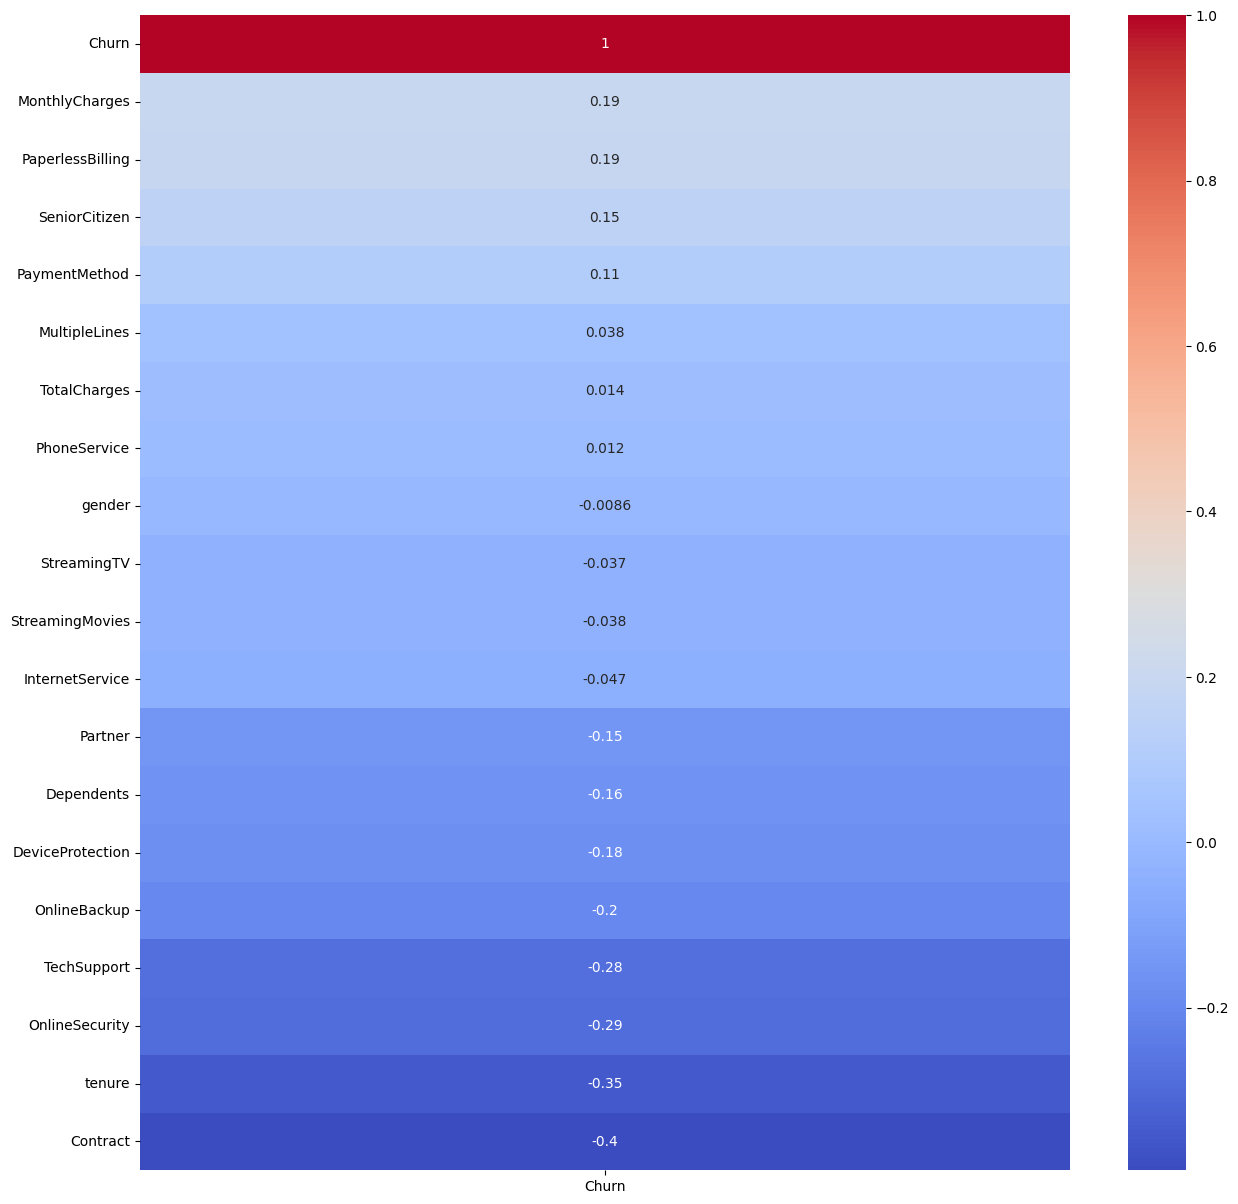

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(corr[['Churn']].sort_values(by='Churn',ascending=False),annot=True,cmap='coolwarm')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(),errors='coerce')

In [ ]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df['SeniorCitizen'] = np.where(df['SeniorCitizen']==1,'Yes','No')

##Train Test Split

In [ ]:
x = df.drop('Churn',axis=1)

In [ ]:
y = df[['Churn']]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=21,test_size=0.2,stratify=y)

In [ ]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

##Null Handling

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
Impute_Total_Charges = SimpleImputer(strategy = 'mean')
x_train['TotalCharges'] = Impute_Total_Charges.fit_transform(x_train[['TotalCharges']])
x_test['TotalCharges'] = Impute_Total_Charges.fit_transform(x_test[['TotalCharges']])

##Outlier Handling

In [ ]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,No,No,No,2,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,82.00,184.65
1,Female,No,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,109.80,3587.25
2,Female,No,No,No,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,Month-to-month,No,Mailed check,66.25,620.55
3,Male,No,Yes,No,67,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,93.15,6368.20
4,Male,No,No,No,71,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),53.95,3888.65


In [ ]:
numerical_columns = [i for i in x_train.select_dtypes(['int','float']).columns]

In [ ]:
numerical_columns

['tenure', 'MonthlyCharges', 'TotalCharges']

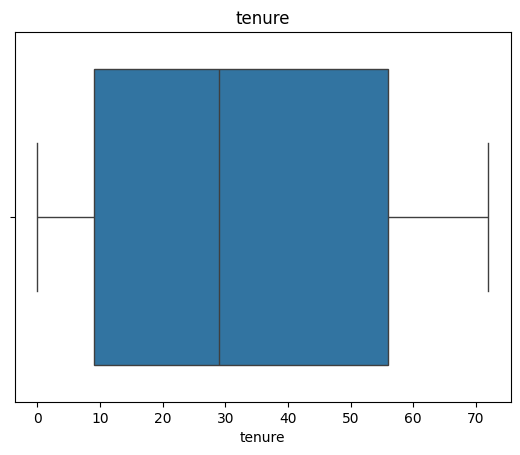

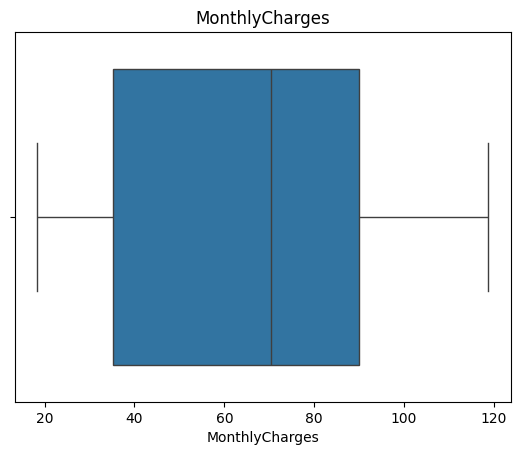

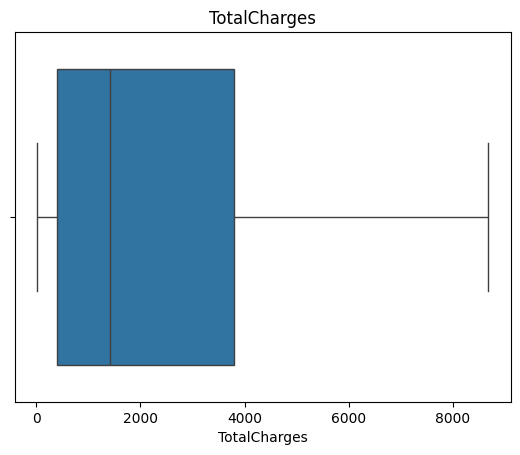

In [ ]:
for i in numerical_columns:
  sns.boxplot(x=x_train[i])
  plt.title(i)
  plt.show()

Outlier handling is not required

##Skew Data handling

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


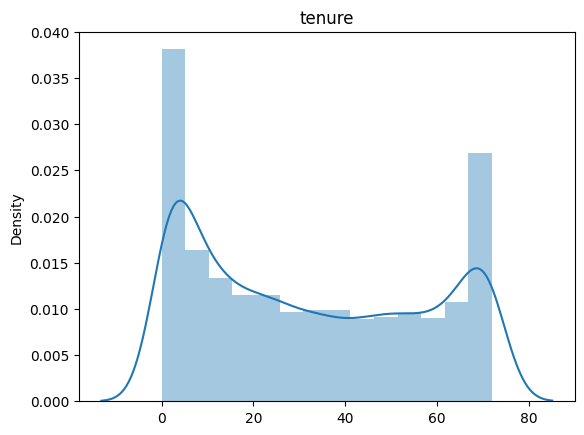

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


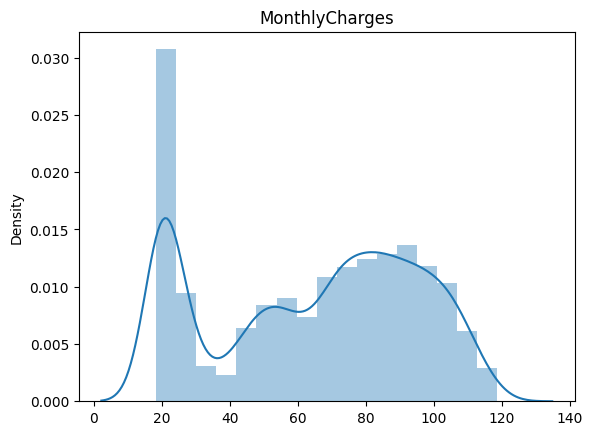

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


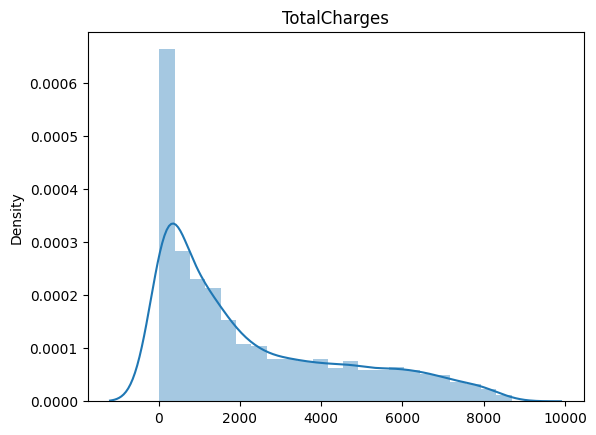

In [ ]:
for i in numerical_columns:
  sns.distplot(x=x_train[i])
  plt.title(i)
  plt.show()

In [ ]:
for i in numerical_columns:
  print(f'Skew of {i} is {x_train[i].skew()}')

Skew of tenure is 0.24154307949177942
Skew of MonthlyCharges is -0.2180067984814727
Skew of TotalCharges is 0.959567310717357


In [ ]:
PT = PowerTransformer(method='yeo-johnson')

In [ ]:
x_train['TotalCharges'] = PT.fit_transform(x_train[['TotalCharges']])

In [ ]:
x_test['TotalCharges'] = PT.transform(x_test[['TotalCharges']])

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


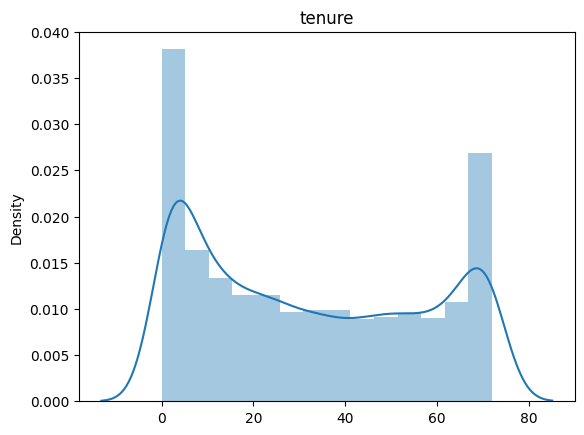

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


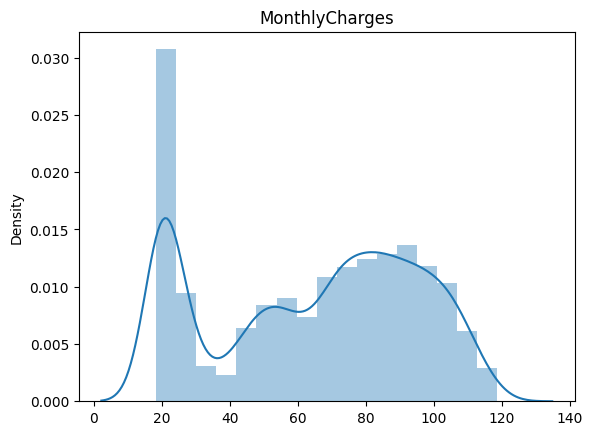

/tmp/ipykernel_2917/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


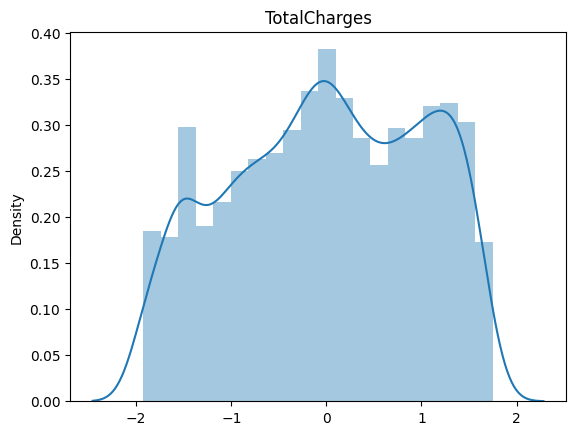

In [ ]:
for i in numerical_columns:
  sns.distplot(x=x_train[i])
  plt.title(i)
  plt.show()

In [ ]:
for i in numerical_columns:
  print(f'Skew of {i} is {x_train[i].skew()}')

Skew of tenure is 0.24154307949177942
Skew of MonthlyCharges is -0.2180067984814727
Skew of TotalCharges is -0.1453161207648667


In [ ]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,No,No,No,2,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,82.00,-1.161250
1,Female,No,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,109.80,0.812024
2,Female,No,No,No,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,Month-to-month,No,Mailed check,66.25,-0.528593
3,Male,No,Yes,No,67,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,93.15,1.396625
4,Male,No,No,No,71,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),53.95,0.889162


In [ ]:
categorical_columns = [i for i in x_train.select_dtypes('object').columns]

##Encoding and Feature Scaling

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   object 
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 


In [ ]:
x_train['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
x_train['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
x_train['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
x_train['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
x_train['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
x_train['MultipleLines'].unique()

array(['Yes', 'No', 'No phone service'], dtype=object)

In [ ]:
x_train['InternetService'].unique()

array(['Fiber optic', 'DSL', 'No'], dtype=object)

In [ ]:
x_train['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
x_train['OnlineBackup'].unique()

array(['Yes', 'No internet service', 'No'], dtype=object)

In [ ]:
x_train['DeviceProtection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
x_train['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
x_train['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
x_train['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [ ]:
x_train['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
x_train['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [ ]:
x_train['StreamingTV'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
ColumnTransformer_Preprocessor = ColumnTransformer([('Ordinal_encoding',OrdinalEncoder(),['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling']),('One_Hot_encoding',OneHotEncoder(sparse_output=False),['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingMovies','Contract','PaymentMethod','StreamingTV']),('Standard Scaling',StandardScaler(),['tenure', 'MonthlyCharges', 'TotalCharges'])],remainder = 'passthrough')

In [ ]:
ColumnTransformer_Preprocessor_y = ColumnTransformer([('Encoding',OrdinalEncoder(),['Churn'])],remainder = 'passthrough')

In [ ]:
pipelines = Pipeline([('Preprocessing',ColumnTransformer_Preprocessor)])

In [ ]:
pipelines_y = Pipeline([('Preprocessing_y',ColumnTransformer_Preprocessor_y)])

In [ ]:
x_train = pd.DataFrame(pipelines.fit_transform(x_train),columns=pipelines.named_steps['Preprocessing'].get_feature_names_out())

In [ ]:
x_test = pd.DataFrame(pipelines.transform(x_test),columns=pipelines.named_steps['Preprocessing'].get_feature_names_out())

In [ ]:
y_train = pd.DataFrame(pipelines_y.fit_transform(y_train),columns=pipelines_y.named_steps['Preprocessing_y'].get_feature_names_out())

In [ ]:
y_test = pd.DataFrame(pipelines_y.transform(y_test),columns=pipelines_y.named_steps['Preprocessing_y'].get_feature_names_out())

In [ ]:
x_train.head()

,Ordinal_encoding__gender,Ordinal_encoding__SeniorCitizen,Ordinal_encoding__Partner,Ordinal_encoding__Dependents,Ordinal_encoding__PhoneService,Ordinal_encoding__PaperlessBilling,One_Hot_encoding__MultipleLines_No,One_Hot_encoding__MultipleLines_No phone service,One_Hot_encoding__MultipleLines_Yes,One_Hot_encoding__InternetService_DSL,...,One_Hot_encoding__PaymentMethod_Bank transfer (automatic),One_Hot_encoding__PaymentMethod_Credit card (automatic),One_Hot_encoding__PaymentMethod_Electronic check,One_Hot_encoding__PaymentMethod_Mailed check,One_Hot_encoding__StreamingTV_No,One_Hot_encoding__StreamingTV_No internet service,One_Hot_encoding__StreamingTV_Yes,Standard Scaling__tenure,Standard Scaling__MonthlyCharges,Standard Scaling__TotalCharges
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.235006,0.571533,-1.161250
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.063208,1.492291,0.812024
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.951022,0.049880,-0.528593
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.401993,0.940830,1.396625
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.564270,-0.357506,0.889162


##Hyper parameter tuning

###Random Forest Classifier

In [ ]:
RF_pipeline = IMBPipeline([('smote',SMOTE(random_state=42)),('model',RandomForestClassifier(random_state=42))])

In [ ]:
params = {'model__n_estimators': [100,150,200,250], 'model__criterion':['gini','entropy'], 'model__max_depth' : [5,10,15], 'model__min_samples_split' : [10,11,12], 'model__max_samples' : [0.4,0.5,0.6], 'model__max_features' : ['sqrt','log2']}

In [ ]:
RandomSearch_RF = RandomizedSearchCV(estimator = RF_pipeline, param_distributions = params, cv = 5, n_iter = 25, return_train_score = True, scoring = 'recall', random_state = 10)

In [ ]:
start_time = time.time()
RandomSearch_RF.fit(x_train,y_train.iloc[:,0])
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

Time Taken in mins : 3.0619815389315286


In [ ]:
RandomSearch_RF_Results = pd.DataFrame(RandomSearch_RF.cv_results_)

In [ ]:
RandomSearch_RF_Results['Train_Score_Minus_Test_Score'] = RandomSearch_RF_Results['mean_train_score'] - RandomSearch_RF_Results['mean_test_score']

In [ ]:
RandomSearch_RF_Results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__n_estimators', 'param_model__min_samples_split',
       'param_model__max_samples', 'param_model__max_features',
       'param_model__max_depth', 'param_model__criterion', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score',
       'Train_Score_Minus_Test_Score'],
      dtype='object')

In [ ]:
RandomSearch_RF_Results[['param_model__n_estimators', 'param_model__min_samples_split','param_model__max_samples', 'param_model__max_features','param_model__max_depth', 'param_model__criterion','mean_train_score','mean_test_score','Train_Score_Minus_Test_Score']].sort_values(by='mean_test_score', ascending = False)

,param_model__n_estimators,param_model__min_samples_split,param_model__max_samples,param_model__max_features,param_model__max_depth,param_model__criterion,mean_train_score,mean_test_score,Train_Score_Minus_Test_Score
3,250,12,0.4,log2,5,gini,0.784783,0.770569,0.014214
11,100,10,0.6,sqrt,5,gini,0.790468,0.770569,0.019900
1,200,10,0.5,log2,5,entropy,0.782609,0.769900,0.012709
18,200,11,0.4,sqrt,5,gini,0.795151,0.767893,0.027258
0,150,11,0.6,log2,5,gini,0.790468,0.767224,0.023244
4,250,12,0.6,log2,5,entropy,0.785786,0.765886,0.019900
21,200,10,0.5,sqrt,5,entropy,0.786120,0.765217,0.020903
6,250,10,0.6,log2,5,entropy,0.785452,0.765217,0.020234
23,200,10,0.4,sqrt,5,entropy,0.787291,0.765217,0.022074
24,200,12,0.4,sqrt,5,entropy,0.786455,0.764548,0.021906


In [ ]:
RandomSearch_RF.best_params_

{'model__n_estimators': 250,
 'model__min_samples_split': 12,
 'model__max_samples': 0.4,
 'model__max_features': 'log2',
 'model__max_depth': 5,
 'model__criterion': 'gini'}

###Gradient Boosting Classifier

In [ ]:
GBC_pipeline = IMBPipeline([('smote',SMOTE(random_state=42)),('model',GradientBoostingClassifier(random_state=42))])

In [ ]:
params = {'model__learning_rate' : [0.1, 0.2, 0.3], 'model__n_estimators' : [100, 125, 150], 'model__min_samples_split' : [10, 15, 20], 'model__min_samples_leaf':[8, 9 ,10], 'model__max_depth' : [10,15], 'model__max_leaf_nodes' : [15,20,25] }

In [ ]:
RandomSearch_GBC = RandomizedSearchCV(estimator = GBC_pipeline, param_distributions = params, cv = 5, n_iter = 25, return_train_score = True, scoring = 'recall')

In [ ]:
start_time = time.time()
RandomSearch_GBC.fit(x_train,y_train.iloc[:,0])
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

Time Taken in mins : 11.38887213865916


In [ ]:
RandomSearch_GBC_Results = pd.DataFrame(RandomSearch_GBC.cv_results_)

In [ ]:
RandomSearch_GBC_Results['Train_Score_Minus_Test_Score'] = RandomSearch_GBC_Results['mean_train_score'] - RandomSearch_GBC_Results['mean_test_score']

In [ ]:
RandomSearch_GBC_Results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__n_estimators', 'param_model__min_samples_split',
       'param_model__min_samples_leaf', 'param_model__max_leaf_nodes',
       'param_model__max_depth', 'param_model__learning_rate', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score',
       'Train_Score_Minus_Test_Score'],
      dtype='object')

In [ ]:
RandomSearch_GBC_Results[['param_model__n_estimators', 'param_model__min_samples_split','param_model__min_samples_leaf', 'param_model__max_leaf_nodes','param_model__max_depth', 'param_model__learning_rate','mean_train_score','mean_test_score', 'Train_Score_Minus_Test_Score']].sort_values(by='mean_test_score', ascending = False)

,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_leaf_nodes,param_model__max_depth,param_model__learning_rate,mean_train_score,mean_test_score,Train_Score_Minus_Test_Score
19,100,20,8,15,10,0.1,0.724582,0.615385,0.109197
5,125,20,10,15,10,0.1,0.735452,0.604682,0.130769
4,150,20,8,15,15,0.1,0.748829,0.604682,0.144147
22,100,15,8,20,15,0.1,0.747157,0.602676,0.144482
20,150,10,10,15,15,0.1,0.746656,0.602007,0.144649
8,125,15,9,15,10,0.1,0.735284,0.600000,0.135284
0,150,15,10,15,10,0.1,0.747492,0.597324,0.150167
3,125,10,8,20,10,0.1,0.765217,0.595987,0.169231
9,150,10,8,20,15,0.1,0.787291,0.595318,0.191973
13,125,10,9,25,10,0.1,0.792475,0.591304,0.201171


In [ ]:
RandomSearch_GBC.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 20,
 'model__min_samples_leaf': 8,
 'model__max_leaf_nodes': 15,
 'model__max_depth': 10,
 'model__learning_rate': 0.1}

###XGBoost

In [ ]:
XGBC_pipeline = IMBPipeline([('smote',SMOTE(random_state=42)),('model',XGBClassifier(random_state=42))])

In [ ]:
params = {'model__n_estimators' : [50,100,150,200,250],'model__learning_rate' : [0.1, 0.3, 0.5], 'model__max_depth' : [5, 7, 10], 'model__reg_alpha' : [0.1, 0.2, 0.3, 0.4, 0.5], 'model__reg_lambda' : [1,2,3,4,5]}

In [ ]:
RandomSearch_XGBC = RandomizedSearchCV(estimator = XGBC_pipeline, param_distributions = params, cv = 5, n_iter = 25, return_train_score = True, scoring = 'recall')

In [ ]:
start_time = time.time()
RandomSearch_XGBC.fit(x_train,y_train)
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

Time Taken in mins : 3.5248031417528787


In [ ]:
RandomSearch_XGBC_Results = pd.DataFrame(RandomSearch_XGBC.cv_results_)

In [ ]:
RandomSearch_XGBC_Results['Train_Score_Minus_Test_Score'] = RandomSearch_XGBC_Results['mean_train_score'] - RandomSearch_XGBC_Results['mean_test_score']

In [ ]:
RandomSearch_XGBC_Results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__reg_lambda', 'param_model__reg_alpha',
       'param_model__n_estimators', 'param_model__max_depth',
       'param_model__learning_rate', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score', 'split0_train_score', 'split1_train_score',
       'split2_train_score', 'split3_train_score', 'split4_train_score',
       'mean_train_score', 'std_train_score', 'Train_Score_Minus_Test_Score'],
      dtype='object')

In [ ]:
RandomSearch_XGBC_Results[['param_model__reg_lambda', 'param_model__reg_alpha',
       'param_model__n_estimators', 'param_model__max_depth',
       'param_model__learning_rate','mean_train_score','mean_test_score', 'Train_Score_Minus_Test_Score']].sort_values(by='mean_test_score', ascending = False)

,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,mean_train_score,mean_test_score,Train_Score_Minus_Test_Score
2,2,0.5,50,5,0.1,0.731271,0.668227,0.063043
19,5,0.5,50,7,0.1,0.763712,0.637458,0.126254
17,3,0.5,50,7,0.1,0.769732,0.633445,0.136288
23,1,0.5,150,5,0.1,0.738294,0.615385,0.122910
22,5,0.1,150,5,0.3,0.824415,0.586622,0.237793
5,2,0.2,100,5,0.3,0.799666,0.584615,0.215050
4,2,0.2,50,5,0.5,0.780100,0.581271,0.198829
15,2,0.5,50,7,0.3,0.852174,0.579264,0.272910
3,3,0.4,50,10,0.3,0.962542,0.572575,0.389967
11,3,0.5,100,5,0.5,0.863378,0.563880,0.299498


In [ ]:
RandomSearch_XGBC.best_params_

{'model__reg_lambda': 2,
 'model__reg_alpha': 0.5,
 'model__n_estimators': 50,
 'model__max_depth': 5,
 'model__learning_rate': 0.1}

##Imabalnced Data handling

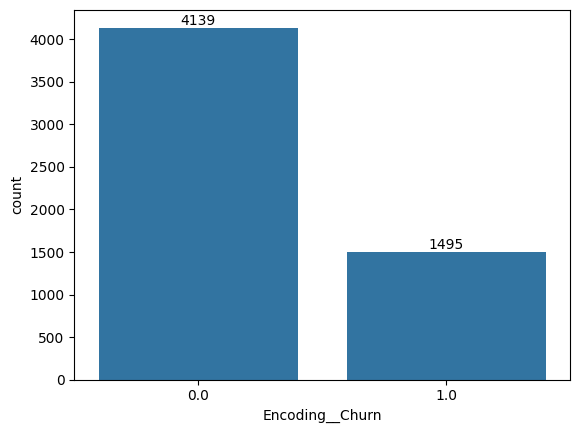

In [ ]:
plot = sns.countplot(x=y_train['Encoding__Churn'])
for i in plot.containers:
  plot.bar_label(i)

In [ ]:
SMOTE_Churn = SMOTE()

In [ ]:
x_train, y_train = SMOTE_Churn.fit_resample(x_train,y_train)

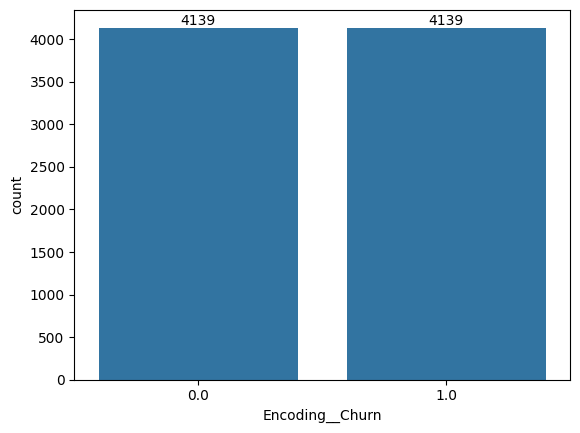

In [ ]:
plot = sns.countplot(x=y_train['Encoding__Churn'])
for i in plot.containers:
  plot.bar_label(i)

##Model Creation

###Random Forest

In [1104]:
RandomSearch_RF = RandomForestClassifier(n_estimators=250,min_samples_split=12,max_samples=0.4,max_features='log2',max_depth=5,criterion='gini',oob_score = True, random_state = 42)

In [1105]:
start_time = time.time()
RandomSearch_RF.fit(x_train,y_train)
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Time Taken in mins : 0.04739451805750529


In [1107]:
y_train_pred_RF = RandomSearch_RF.predict(x_train)

In [1108]:
y_test_pred_RF = RandomSearch_RF.predict(x_test)

In [1109]:
y_test_proba_RF = RandomSearch_RF.predict_proba(x_test)[:,1]

In [1110]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]

####Accuracy

In [1111]:
accuracy_score(y_train,y_train_pred_RF)

0.7949987919787388

In [1112]:
accuracy_score(y_test,y_test_pred_RF)

0.7402413058907026

####Precision

In [1113]:
precision_score(y_test,y_test_pred_RF)

0.506993006993007

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


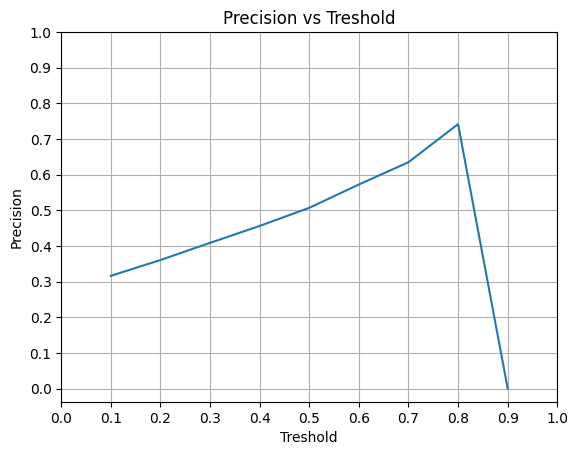

In [1195]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
precision_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_RF>i).astype('int')
  precision_test.append(precision_score(y_test,y_pred_test_treshold))
plt.plot(treshold, precision_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.ylabel('Precision')
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.title('Precision vs Treshold')
plt.grid()
plt.show()

####Recall

In [1115]:
recall_score(y_test,y_test_pred_RF)

0.7754010695187166

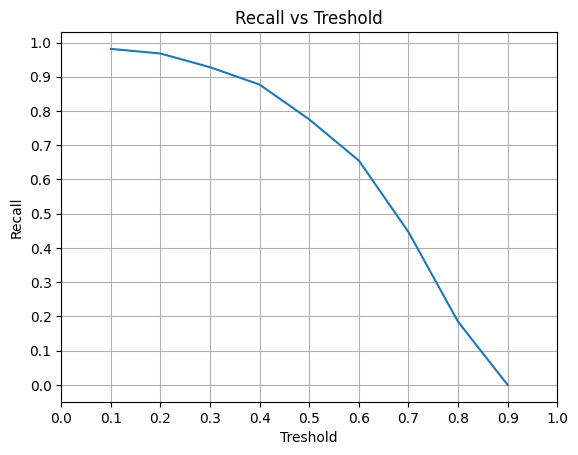

In [1206]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
recall_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_RF>i).astype('int')
  recall_test.append(recall_score(y_test,y_pred_test_treshold))
plt.plot(treshold, recall_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.ylabel('Recall')
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.title('Recall vs Treshold')
plt.grid()
plt.show()

####Precision Recall Curve

In [1119]:
precision, recall, threshold = precision_recall_curve(y_test,y_test_proba_RF)

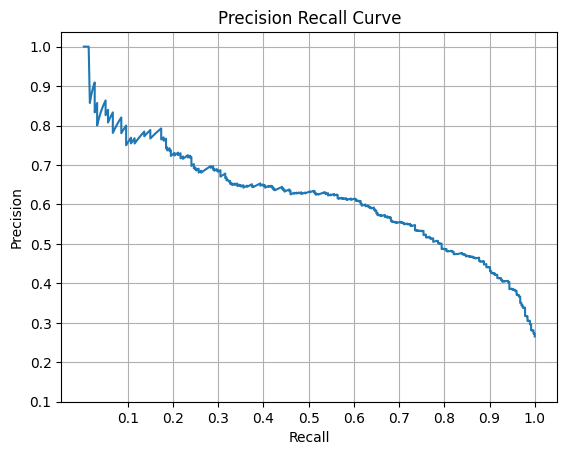

In [1120]:
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(recall[:-1], precision[:-1])
plt.title('Precision Recall Curve')
plt.xticks([i for i in np.arange(0.1,1.1,0.1)])
plt.yticks([i for i in np.arange(0.1,1.1,0.1)])
plt.grid()
plt.show()

####F2 Score

In [1121]:
fbeta_score(y_test,y_test_pred_RF,beta=2)

0.7011605415860735

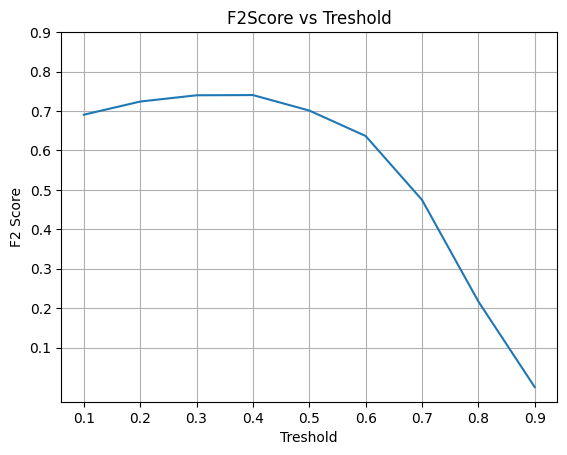

In [1193]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
f2_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_RF>i).astype('int')
  f2_test.append(fbeta_score(y_test,y_pred_test_treshold,beta=2))
plt.plot(treshold, f2_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.1,1,0.1)])
plt.ylabel('F2 Score')
plt.yticks([i for i in np.arange(0.1,1,0.1)])
plt.title('F2Score vs Treshold')
plt.grid()
plt.show()

####ROC Curve

In [1123]:
fpr, tpr, treshold = roc_curve(y_test,y_test_pred_RF)

In [1124]:
auc_score = roc_auc_score(y_test,y_test_pred_RF)

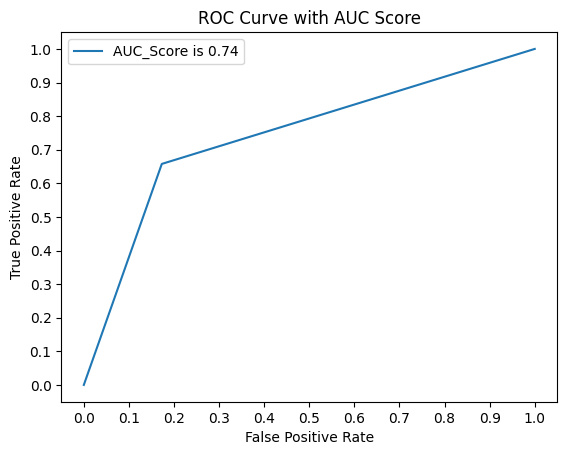

In [1207]:
plt.plot(fpr,tpr,label=f'AUC_Score is {round(auc_score,2)}')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with AUC Score')
plt.legend()
plt.show()

###Gradient Boosting Classifier

In [1126]:
model = GradientBoostingClassifier(n_estimators = 100, min_samples_split=20, min_samples_leaf=8, max_leaf_nodes=15, max_depth=10, learning_rate=0.1, random_state = 42)

In [1127]:
start_time = time.time()
model.fit(x_train,y_train)
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Time Taken in mins : 0.09034201304117838


In [1129]:
y_train_pred_GBC = RandomSearch_GBC.predict(x_train)

In [1130]:
y_test_pred_GBC = RandomSearch_GBC.predict(x_test)

In [1131]:
y_test_proba_GBC = RandomSearch_GBC.predict_proba(x_test)[:,1]

In [1132]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]

####Accuracy

In [1133]:
accuracy_score(y_train,y_train_pred_GBC)

0.8840299589272771

In [1134]:
accuracy_score(y_test,y_test_pred_GBC)

0.7892122072391767

####Precision

In [1136]:
precision_score(y_test,y_test_pred_GBC)

0.6032171581769437

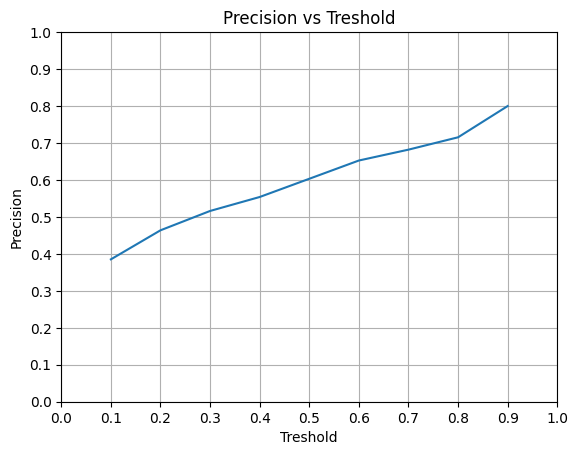

In [1192]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
precision_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_GBC>i).astype('int')
  precision_test.append(precision_score(y_test,y_pred_test_treshold))
plt.plot(treshold, precision_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.ylabel('Precision')
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.title('Precision vs Treshold')
plt.grid()
plt.show()

####Recall

In [1138]:
recall_score(y_test,y_test_pred_GBC)

0.6016042780748663

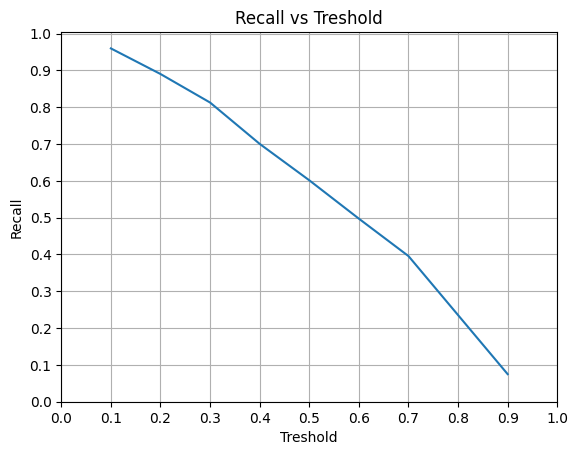

In [1191]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
recall_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_GBC>i).astype('int')
  recall_test.append(recall_score(y_test,y_pred_test_treshold))
plt.plot(treshold, recall_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.0,1.1,0.1)])
plt.ylabel('Recall')
plt.yticks([i for i in np.arange(0.0,1.1,0.1)])
plt.title('Recall vs Treshold')
plt.grid()
plt.show()

####Precision Recall Curve

In [1143]:
precision, recall, threshold = precision_recall_curve(y_test,y_test_proba_RF)

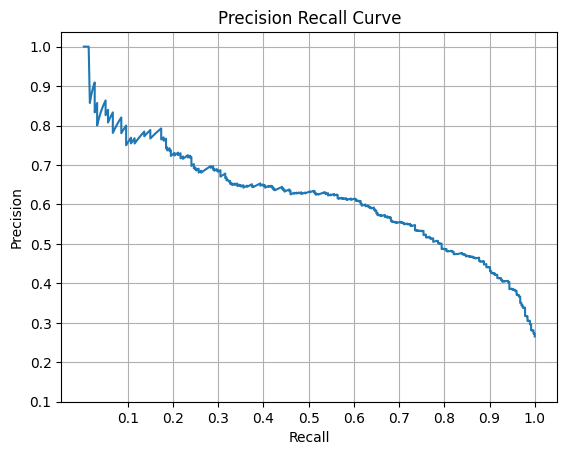

In [1144]:
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(recall[:-1], precision[:-1])
plt.title('Precision Recall Curve')
plt.xticks([i for i in np.arange(0.1,1.1,0.1)])
plt.yticks([i for i in np.arange(0.1,1.1,0.1)])
plt.grid()
plt.show()

####F2 Score

In [1145]:
fbeta_score(y_test,y_test_pred_GBC,beta=2)

0.6019261637239165

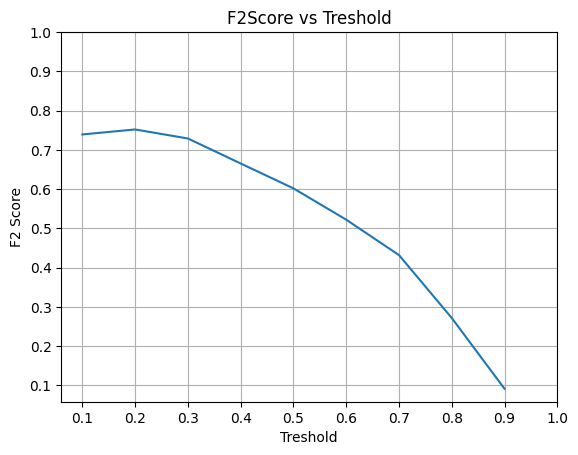

In [1190]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
f2_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_GBC>i).astype('int')
  f2_test.append(fbeta_score(y_test,y_pred_test_treshold,beta=2))
plt.plot(treshold, f2_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.1,1.1,0.1)])
plt.ylabel('F2 Score')
plt.yticks([i for i in np.arange(0.1,1.1,0.1)])
plt.title('F2Score vs Treshold')
plt.grid()
plt.show()

####ROC Curve

In [1148]:
fpr, tpr, treshold = roc_curve(y_test,y_test_pred_GBC)

In [1150]:
auc_score = roc_auc_score(y_test,y_test_pred_GBC)

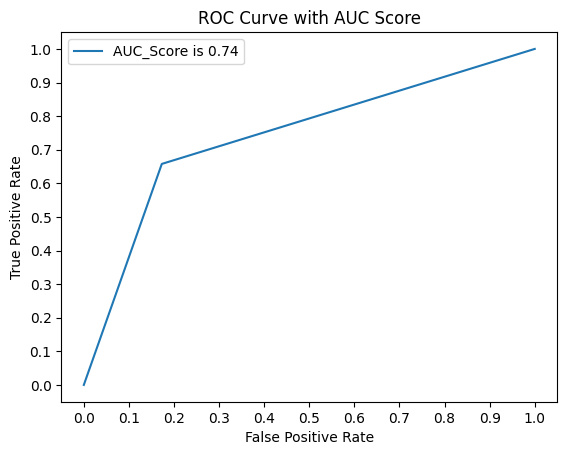

In [1208]:
plt.plot(fpr,tpr,label=f'AUC_Score is {round(auc_score,2)}')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with AUC Score')
plt.legend()
plt.show()

###XGBoost Classifier

In [1152]:
model = XGBClassifier(reg_lambda = 2, reg_alpha = 0.5, n_estimators = 50, max_depth = 5, learning_rate = 0.1, random_state = 42)

In [1153]:
start_time = time.time()
model.fit(x_train,y_train)
end_time = time.time()
print(f'Time Taken in mins : {(end_time-start_time)/60}')

Time Taken in mins : 0.005554513136545817


In [1154]:
y_train_pred_XGBC = RandomSearch_XGBC.predict(x_train)

In [1155]:
y_test_pred_XGBC = RandomSearch_XGBC.predict(x_test)

In [1156]:
y_test_proba_XGBC = RandomSearch_XGBC.predict_proba(x_test)[:,1]

In [1157]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]

####Accuracy

In [1158]:
accuracy_score(y_train,y_train_pred_XGBC)

0.8618023677216718

In [1159]:
accuracy_score(y_test,y_test_pred_XGBC)

0.7821149751596878

####Precision

In [1160]:
precision_score(y_test,y_test_pred_XGBC)

0.5788235294117647

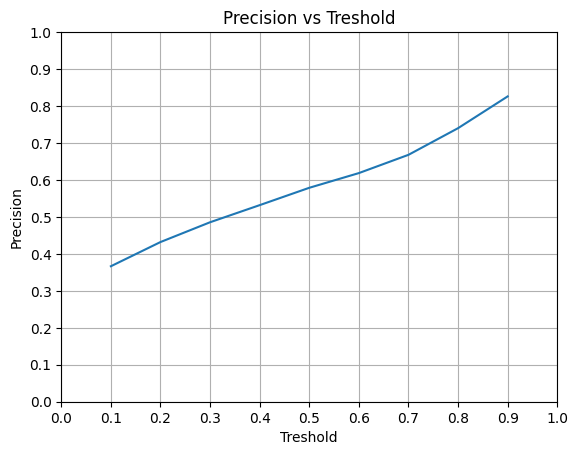

In [1186]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
precision_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_XGBC>i).astype('int')
  precision_test.append(precision_score(y_test,y_pred_test_treshold))
plt.plot(treshold, precision_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.ylabel('Precision')
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.title('Precision vs Treshold')
plt.grid()
plt.show()

####Recall

In [1162]:
recall_score(y_test,y_test_pred_XGBC)

0.6577540106951871

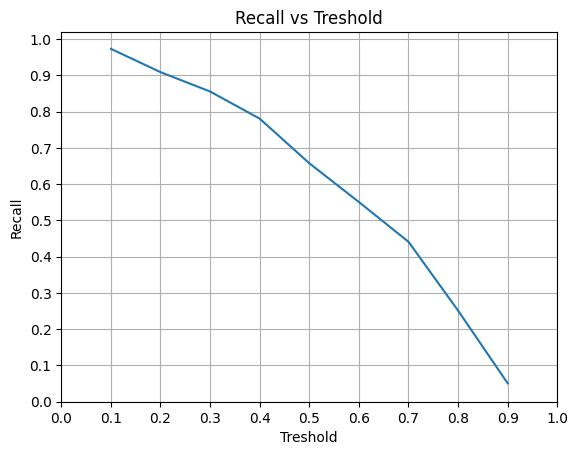

In [1187]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
recall_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_XGBC>i).astype('int')
  recall_test.append(recall_score(y_test,y_pred_test_treshold))
plt.plot(treshold, recall_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.0,1.1,0.1)])
plt.ylabel('Recall')
plt.yticks([i for i in np.arange(0.0,1.1,0.1)])
plt.title('Recall vs Treshold')
plt.grid()
plt.show()

####Precision Recall Curve

In [1166]:
precision, recall, threshold = precision_recall_curve(y_test,y_test_proba_XGBC)

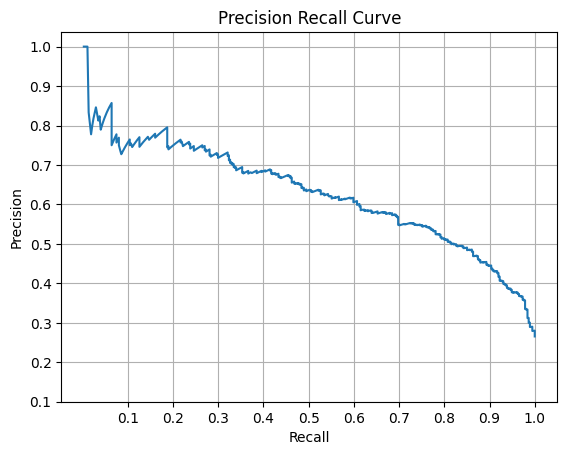

In [1167]:
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(recall[:-1], precision[:-1])
plt.title('Precision Recall Curve')
plt.xticks([i for i in np.arange(0.1,1.1,0.1)])
plt.yticks([i for i in np.arange(0.1,1.1,0.1)])
plt.grid()
plt.show()

####F2 Score

In [1168]:
fbeta_score(y_test,y_test_pred_XGBC,beta=2)

0.6402915148360229

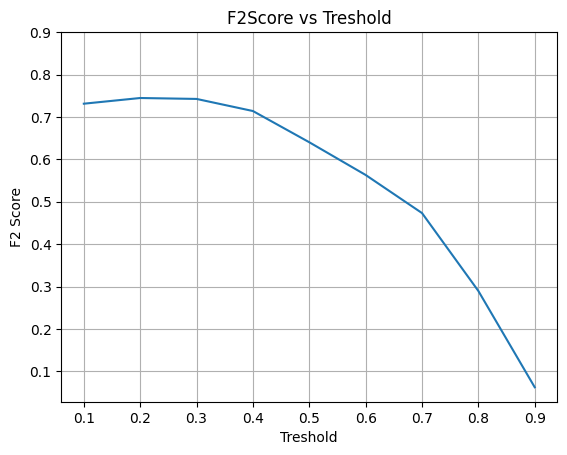

In [1188]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
f2_test = []
for i in treshold:
  y_pred_test_treshold = (y_test_proba_XGBC>i).astype('int')
  f2_test.append(fbeta_score(y_test,y_pred_test_treshold,beta=2))
plt.plot(treshold, f2_test)
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.1,1,0.1)])
plt.ylabel('F2 Score')
plt.yticks([i for i in np.arange(0.1,1,0.1)])
plt.title('F2Score vs Treshold')
plt.grid()
plt.show()

####ROC Curve

In [1170]:
fpr, tpr, treshold = roc_curve(y_test,y_test_pred_XGBC)

In [1171]:
auc_score = roc_auc_score(y_test,y_test_pred_XGBC)

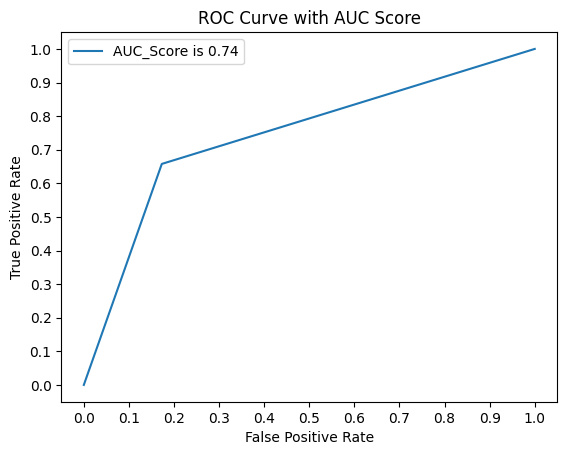

In [1209]:
plt.plot(fpr,tpr,label=f'AUC_Score is {round(auc_score,2)}')
plt.xticks([i for i in np.arange(0,1.1,0.1)])
plt.yticks([i for i in np.arange(0,1.1,0.1)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with AUC Score')
plt.legend()
plt.show()

##Comparing the models

In [1173]:
print(f'Recall of Random Forest is {recall_score(y_test,y_test_pred_RF)}')
print(f'Recall of Gradient Boosting Classifier is {recall_score(y_test,y_test_pred_GBC)}')
print(f'Recall of XGBoost Classifier is {recall_score(y_test,y_test_pred_XGBC)}')

Recall of Random Forest is 0.7754010695187166
Recall of Gradient Boostin Classifier is 0.6016042780748663
Recall of XGBoost Classifier is 0.6577540106951871


In [1174]:
print(f'Recall of Random Forest is {fbeta_score(y_test,y_test_pred_RF,beta=2)}')
print(f'Recall of Gradient Boosting Classifier is {fbeta_score(y_test,y_test_pred_GBC,beta=2)}')
print(f'Recall of XGBoost Classifier is {fbeta_score(y_test,y_test_pred_XGBC,beta=2)}')

Recall of Random Forest is 0.7011605415860735
Recall of Gradient Boosting Classifier is 0.6019261637239165
Recall of XGBoost Classifier is 0.6402915148360229


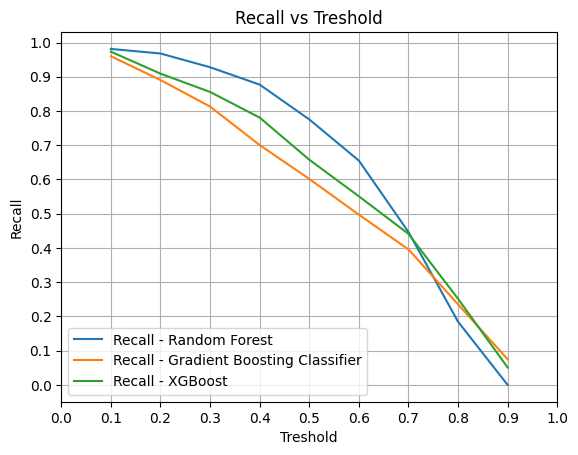

In [1189]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
recall_RF = []
recall_GBC = []
recall_XGBC = []
for i in treshold:
  y_pred_test_treshold_RF = (y_test_proba_RF>i).astype('int')
  y_pred_test_treshold_GBC = (y_test_proba_GBC>i).astype('int')
  y_pred_test_treshold_XGBC = (y_test_proba_XGBC>i).astype('int')
  recall_RF.append(recall_score(y_test,y_pred_test_treshold_RF))
  recall_GBC.append(recall_score(y_test,y_pred_test_treshold_GBC))
  recall_XGBC.append(recall_score(y_test,y_pred_test_treshold_XGBC))
plt.plot(treshold, recall_RF,label= 'Recall - Random Forest')
plt.plot(treshold, recall_GBC,label= 'Recall - Gradient Boosting Classifier')
plt.plot(treshold, recall_XGBC,label= 'Recall - XGBoost')
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.0,1.1,0.1)])
plt.ylabel('Recall')
plt.yticks([i for i in np.arange(0.0,1.1,0.1)])
plt.title('Recall vs Treshold')
plt.legend()
plt.grid()
plt.show()

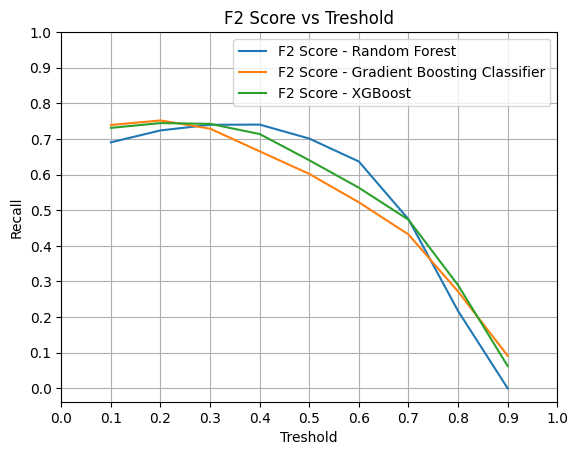

In [1198]:
treshold = [round(i,1) for i in np.arange(0.1,1,0.1)]
f2_RF = []
f2_GBC = []
f2_XGBC = []
for i in treshold:
  y_pred_test_treshold_RF = (y_test_proba_RF>i).astype('int')
  y_pred_test_treshold_GBC = (y_test_proba_GBC>i).astype('int')
  y_pred_test_treshold_XGBC = (y_test_proba_XGBC>i).astype('int')
  f2_RF.append(fbeta_score(y_test,y_pred_test_treshold_RF,beta=2))
  f2_GBC.append(fbeta_score(y_test,y_pred_test_treshold_GBC,beta=2))
  f2_XGBC.append(fbeta_score(y_test,y_pred_test_treshold_XGBC,beta=2))
plt.plot(treshold, f2_RF,label= 'F2 Score - Random Forest')
plt.plot(treshold, f2_GBC,label= 'F2 Score - Gradient Boosting Classifier')
plt.plot(treshold, f2_XGBC,label= 'F2 Score - XGBoost')
plt.xlabel('Treshold')
plt.xticks([i for i in np.arange(0.0,1.1,0.1)])
plt.ylabel('Recall')
plt.yticks([i for i in np.arange(0.0,1.1,0.1)])
plt.title('F2 Score vs Treshold')
plt.legend()
plt.grid()
plt.show()

In [1197]:
print(f'AUC Score of Random Forest is {roc_auc_score(y_test,y_test_pred_RF)}')
print(f'AUC Score of Random Forest is {roc_auc_score(y_test,y_test_pred_GBC)}')
print(f'AUC Score of Random Forest is {roc_auc_score(y_test,y_test_pred_XGBC)}')

AUC Score of Random Forest is 0.7514686507013872
AUC Score of Random Forest is 0.7293045544963703
AUC Score of Random Forest is 0.7424035753959027


In this case recall is more important than precision so precision, f2 score is compared among the models. Random Forest Classifier at 0.4 treshold highest recall and f2score.

On comparing AUC score Random Forest model posses high AUC score

In [1204]:
y_pred_final = (y_test_proba_RF>=0.4).astype('int')
print(f'Recall score of Random Forest model at threshold 0.4 - {recall_score(y_test,y_pred_final)}')
print(f'F2 score of Random Forest model at threshold 0.4 - {fbeta_score(y_test,y_pred_final,beta=2)}')

Recall score of Random Forest model at threshold 0.4 - 0.8770053475935828
F2 score of Random Forest model at threshold 0.4 - 0.7404063205417607
